# Working with FleXgeo2 results in memory

This notebook keeps the analysis in memory and shows how to ask common questions of the FleXgeo2 dataframes. It also demonstrates the lower-level `GeometryService` workflow that powers the high-level app.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "pdb2lj5.pdb").is_file():
            return candidate
    raise FileNotFoundError("Could not find the FleXgeo2 repo root containing pyproject.toml and pdb2lj5.pdb")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import matplotlib.pyplot as plt
    import melodia_py  # noqa: F401
    import pandas as pd
    from flexgeo2 import AnalysisConfig, FlexGeo2App, OutputConfig
    from flexgeo2.geometry import GeometryService
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f"Missing dependency: {exc.name}. Install the project in your notebook kernel with `pip install -e .` "
        "or, if you use uv, run `uv sync` and select the project environment as the Jupyter kernel."
    ) from exc

PDB_FILE = REPO_ROOT / "pdb2lj5.pdb"
print(f"Using {PDB_FILE}")

Using /Users/marinho/Projects/flexgeo2/pdb2lj5.pdb


## Run without writing files

Use `OutputConfig(write_files=False)` when you want the dataframes but do not want FleXgeo2 to create CSV or PNG files.

In [2]:
result = FlexGeo2App().run(
    AnalysisConfig(
        pdb_file=PDB_FILE,
        chains=["A"],
        n_jobs=1,
        output=OutputConfig(write_files=False),
    )
)

print(type(result.outputs).__name__)
result.residue_summary_df.head()

OutputArtifacts


,chain,order,name,residue_label,curvature_mean,curvature_std,curvature_min,curvature_max,torsion_mean,torsion_std,torsion_min,torsion_max,models
0,A,1,MET,MET1,0.514353,0.064986,0.325864,0.699961,-0.009660,0.013937,-0.051142,0.036073,301
1,A,2,GLN,GLN2,0.514353,0.064986,0.325864,0.699961,-0.009660,0.013937,-0.051142,0.036073,301
2,A,3,ILE,ILE3,0.583653,0.065199,0.419426,0.815847,-0.085308,0.013672,-0.121378,-0.036480,301
3,A,4,PHE,PHE4,0.616037,0.076530,0.414580,0.939250,-0.120778,0.010640,-0.151191,-0.077521,301
4,A,5,VAL,VAL5,0.834924,0.097212,0.603803,1.123519,-0.103026,0.011403,-0.148288,-0.065921,301


## The lower-level geometry flow

`GeometryService` is useful when you want to control each transformation step yourself.

In [3]:
geometry = GeometryService()
raw_df = geometry.load_structure(PDB_FILE, n_jobs=1)
chain_a_df = geometry.filter_chains(raw_df, ["A"])
chain_a_df = geometry.normalize(chain_a_df)
residue_summary_df = geometry.summarize(chain_a_df)
model_summary_df, overall_model_summary_df = geometry.build_model_summary(chain_a_df, residue_summary_df)

print(f"Raw shape: {chain_a_df.shape}")
print(f"Residue summary shape: {residue_summary_df.shape}")
print(f"Model summary shape: {model_summary_df.shape}")

Raw shape: (22876, 13)
Residue summary shape: (76, 13)
Model summary shape: (301, 9)


## Find residues with the most ensemble variation

Large standard deviations highlight residues whose geometry varies more across the submitted models.

In [4]:
top_curvature_variability = residue_summary_df.sort_values("curvature_std", ascending=False).head(10)
top_curvature_variability[["chain", "residue_label", "curvature_mean", "curvature_std", "models"]]

,chain,residue_label,curvature_mean,curvature_std,models
75,A,GLY76,0.305094,0.243417,301
74,A,GLY75,0.305094,0.243417,301
9,A,GLY10,1.132318,0.210256,301
10,A,LYS11,0.735766,0.175236,301
11,A,THR12,0.772205,0.170665,301
7,A,LEU8,0.929012,0.160316,301
73,A,ARG74,0.318828,0.147123,301
71,A,ARG72,0.298803,0.141939,301
8,A,THR9,0.807509,0.132048,301
15,A,GLU16,0.888962,0.125158,301


In [5]:
top_torsion_variability = residue_summary_df.sort_values("torsion_std", ascending=False).head(10)
top_torsion_variability[["chain", "residue_label", "torsion_mean", "torsion_std", "models"]]

,chain,residue_label,torsion_mean,torsion_std,models
75,A,GLY76,-0.094253,0.653691,301
74,A,GLY75,-0.094253,0.653691,301
71,A,ARG72,-0.414268,0.396392,301
61,A,GLN62,-0.242240,0.394726,301
70,A,LEU71,-0.845563,0.366972,301
72,A,LEU73,-0.190516,0.328267,301
67,A,HIS68,-0.938925,0.320326,301
73,A,ARG74,-0.112547,0.275670,301
65,A,THR66,-1.056246,0.263078,301
69,A,VAL70,-0.685893,0.248960,301


## Find models that differ most from the ensemble mean

The mean absolute deviation columns summarize how far each model is from the ensemble-average residue profile.

In [6]:
overall_model_summary_df.assign(
    combined_mean_abs_deviation=lambda df: df["curvature_mean_abs_deviation"] + df["torsion_mean_abs_deviation"]
).sort_values("combined_mean_abs_deviation", ascending=False).head(10)

,model,residues,curvature_mean,torsion_mean,curvature_mean_abs_deviation,torsion_mean_abs_deviation,combined_mean_abs_deviation
62,62,76,0.413867,-0.204488,0.092018,0.131019,0.223037
47,47,76,0.412513,-0.237133,0.069032,0.151025,0.220056
78,78,76,0.427104,-0.000463,0.066092,0.141491,0.207583
236,236,76,0.423980,-0.046785,0.052396,0.130109,0.182505
258,258,76,0.416241,-0.062520,0.054130,0.120098,0.174228
48,48,76,0.453448,-0.113166,0.071663,0.095774,0.167437
126,126,76,0.441604,-0.097161,0.088048,0.078031,0.166079
120,120,76,0.464785,-0.099133,0.099112,0.066413,0.165524
191,191,76,0.421315,-0.211062,0.051082,0.108417,0.159499
0,0,76,0.405282,-0.156256,0.069587,0.089139,0.158726


## Plot one residue across the ensemble

Here we choose the residue with the largest torsion standard deviation and plot its curvature/torsion points for every model.

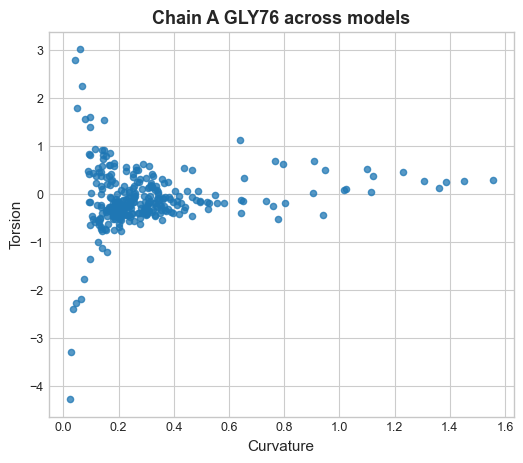

In [7]:
selected = top_torsion_variability.iloc[0]
selected_residue = chain_a_df[chain_a_df["order"] == selected["order"]].copy()

ax = selected_residue.plot.scatter(
    x="curvature",
    y="torsion",
    figsize=(6, 5),
    alpha=0.75,
    title=f"Chain {selected['chain']} {selected['residue_label']} across models",
)
ax.set_xlabel("Curvature")
ax.set_ylabel("Torsion")
plt.show()